# Decision Tree Regression Model

This notebook trains a **Decision Tree Regressor** using the common preprocessed dataset.

**Prerequisite:** Run `00_common_preprocessing.ipynb` first to generate the preprocessed data.

**Note:** Decision Trees do NOT require feature scaling, so we use unscaled data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Common Preprocessed Data

Decision Trees use **unscaled** features (scale-invariant algorithm).

In [2]:
# Load preprocessed data (UNSCALED for Decision Tree )
data_dir = '../data/preprocessed'

X_train = pd.read_csv(f'{data_dir}/X_train.csv')
X_test = pd.read_csv(f'{data_dir}/X_test.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{data_dir}/y_test.csv').squeeze()
feature_names = joblib.load(f'{data_dir}/feature_names.pkl')

print("=" * 50)
print("COMMON PREPROCESSED DATA LOADED")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Feature names: {feature_names}")
print(f"\nUsing UNSCALED data (Decision Trees are scale-invariant).")

COMMON PREPROCESSED DATA LOADED
Training set: 5285 samples
Testing set:  1322 samples
Features: 19
Feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Using UNSCALED data (Decision Trees are scale-invariant).


## 2. Train Decision Tree with Default Settings

In [3]:
# Train decision tree with default settings first
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

print("Model trained successfully with default settings.")
print(f"Tree Depth (default): {dt_model.get_depth()}")
print(f"Number of Leaves (default): {dt_model.get_n_leaves()}")

Model trained successfully with default settings.
Tree Depth (default): 20
Number of Leaves (default): 2910


## 3. Hyperparameter Tuning — Optimal Depth

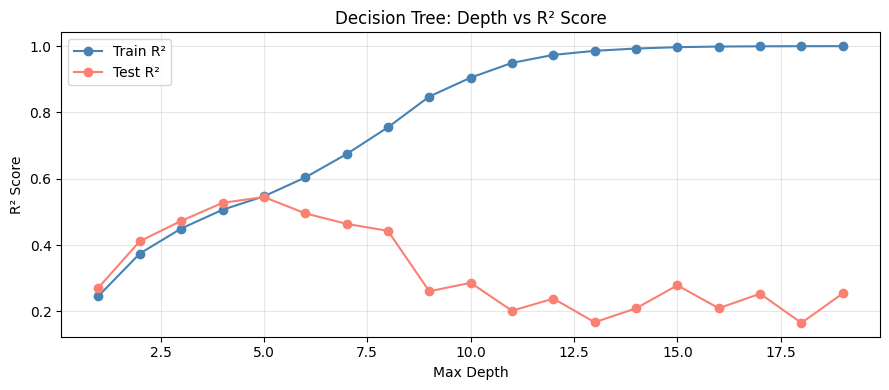


Best max_depth: 5 (Test R²: 0.5448)


In [4]:
# Tune max depth to prevent overfitting
depths = range(1, 20)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

# Plot depth vs R² score
plt.figure(figsize=(9, 4))
plt.plot(depths, train_scores, label='Train R²', marker='o', color='steelblue')
plt.plot(depths, test_scores,  label='Test R²',  marker='o', color='salmon')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree: Depth vs R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"\nBest max_depth: {best_depth} (Test R²: {max(test_scores):.4f})")

In [5]:
# Re-train final model with best depth
dt_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_model.fit(X_train, y_train)

print(f"Retrained with max_depth={best_depth}")
print(f"Tree depth  : {dt_model.get_depth()}")
print(f"Leaf nodes  : {dt_model.get_n_leaves()}")

Retrained with max_depth=5
Tree depth  : 5
Leaf nodes  : 31


## 4. Evaluate the Model

In [6]:
# Make predictions and evaluate
y_pred = dt_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Decision Tree Results =====")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")

===== Decision Tree Results =====
Mean Absolute Error (MAE) : 1.5896
Root Mean Squared Error   : 2.5366
R² Score                  : 0.5448


## 5. Cross-Validation

In [7]:
# Cross-validation score for robustness check
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

cv_scores = cross_val_score(dt_model, X_all, y_all, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores : {cv_scores.round(4)}")
print(f"Mean CV R²                 : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-Validation R² Scores : [0.5172 0.6135 0.503  0.3708 0.5447]
Mean CV R²                 : 0.5098 (+/- 0.0792)


## 6. Visualizations

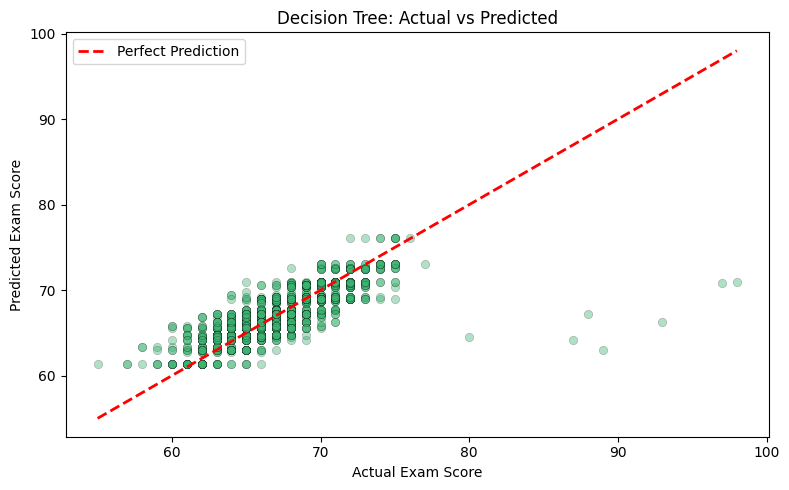

In [8]:
# Plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='mediumseagreen', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Decision Tree: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

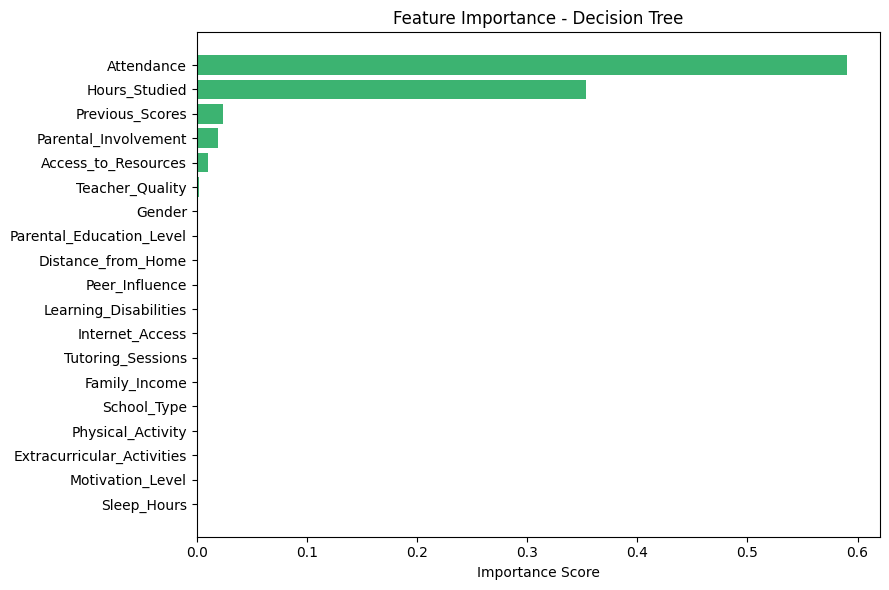

In [9]:
# Plot: Feature Importance
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='mediumseagreen')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

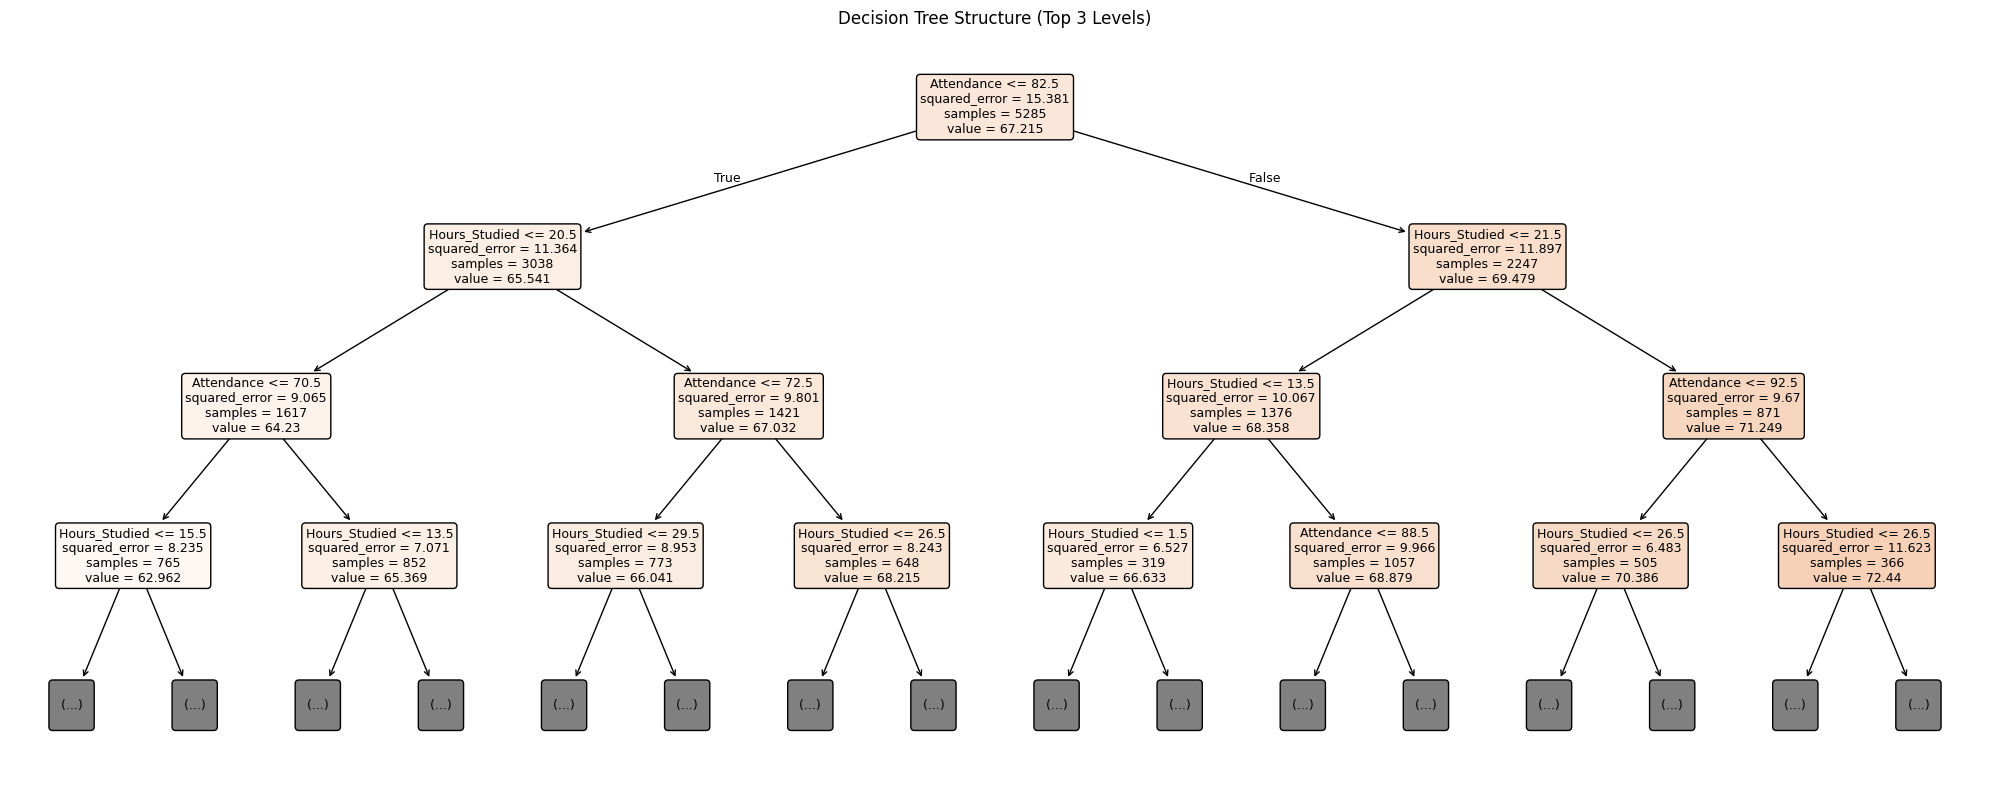

In [10]:
# Visualize the top 3 levels of the decision tree
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    filled=True,
    max_depth=3,
    fontsize=9,
    rounded=True
)
plt.title('Decision Tree Structure (Top 3 Levels)')
plt.tight_layout()
plt.show()

## 7. Save the Model

In [11]:
# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(dt_model, '../models/decision_tree_model.pkl')

# Save metrics for comparison
metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
joblib.dump(metrics, '../models/decision_tree_metrics.pkl')

print("Model saved to ../models/decision_tree_model.pkl")
print(f"Metrics saved: {metrics}")

Model saved to ../models/decision_tree_model.pkl
Metrics saved: {'MAE': 1.5895510128858812, 'RMSE': np.float64(2.5365590170053114), 'R2': 0.5448108484045149}
